In [1]:
# this notebook will normalize the data
# while keeping key level as feature
import pandas as pd
import json
from pathlib import Path


folder_path = Path.cwd().parents[1] / "data" / "mlData"
src_path = folder_path / "BTCUSD-15m-input.jsonl"

# Read JSONL file - keep timestamp as raw number
df = pd.read_json(src_path, lines=True, convert_dates=False)
df.head()

,timestamp,isSTR,isITR,isLTR,barsSinceITR,barsSinceLTR,hiDTK_LTR,lowDTK_LTR,closeDTK_LTR,hiDTK_ITR,lowDTK_ITR,closeDTK_ITR,Y
0,1708659900000,0,0,0,0,0,0.001328,0.000000,0.000936,0.001328,0.000000,0.000936,-1
1,1708660800000,0,0,0,1,1,0.001071,-0.000964,0.000777,0.001071,-0.000964,0.000777,1
2,1708661700000,0,0,0,2,2,0.003613,-0.000413,0.003613,0.003613,-0.000413,0.003613,-1
3,1708662600000,0,0,0,3,3,0.005283,0.002566,0.003366,0.005283,0.002566,0.003366,-1
4,1708663500000,0,0,0,4,4,0.003957,0.002814,0.003279,0.003957,0.002814,0.003279,-1


In [2]:
df.shape

(70929, 13)

In [3]:
# PACF Analysis — determine optimal sequence length
# Looks at how far back each feature is autocorrelated.
# The lag where PACF drops into the noise band (~0) is the min meaning

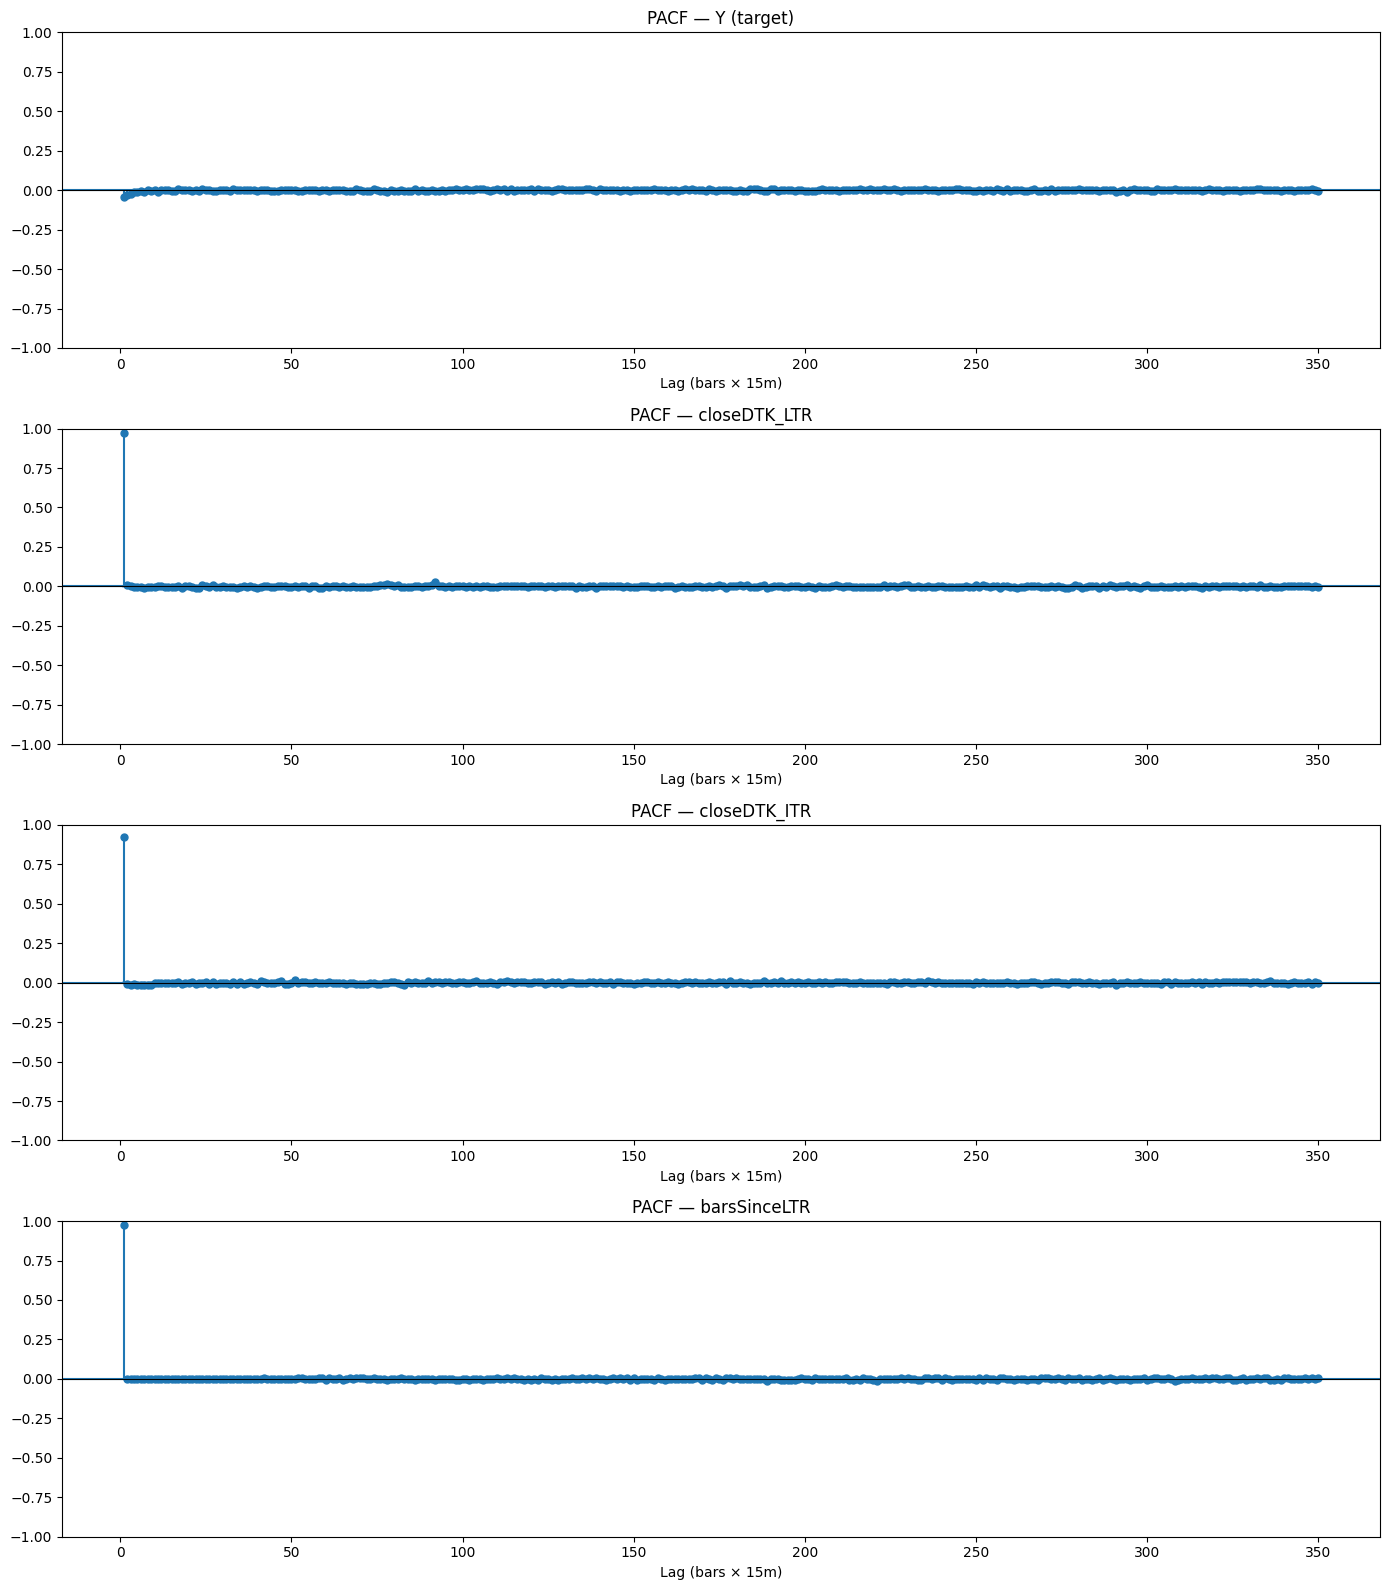

In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Key features to inspect — target + the two most informative continuous features
pacf_targets = {
    "Y (target)":         df["Y"],
    "closeDTK_LTR":       df["closeDTK_LTR"],
    "closeDTK_ITR":       df["closeDTK_ITR"],
    "barsSinceLTR":       df["barsSinceLTR"],
}

MAX_LAGS = 350  # upper bound to search; covers worst-case LTR run (328 bars)

fig, axes = plt.subplots(len(pacf_targets), 1, figsize=(14, 4 * len(pacf_targets)))

for ax, (label, series) in zip(axes, pacf_targets.items()):
    plot_pacf(series, lags=MAX_LAGS, method="ywm", ax=ax, zero=False)
    ax.set_title(f"PACF — {label}")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Lag (bars × 15m)")

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from statsmodels.tsa.stattools import pacf

# Numerically find the last lag that exceeds the 95% confidence band
# confidence_interval = 1.96 / sqrt(N)
N = len(df)
ci = 1.96 / np.sqrt(N)

print(f"95% confidence band: ±{ci:.4f}  (anything inside = noise)\n")

for label, series in pacf_targets.items():
    pacf_vals = pacf(series, nlags=MAX_LAGS, method="ywm")
    significant_lags = np.where(np.abs(pacf_vals[1:]) > ci)[0] + 1  # exclude lag 0
    if len(significant_lags) > 0:
        cutoff = int(significant_lags[-1])
        print(f"{label:20s}  last significant lag: {cutoff:4d}  ({cutoff * 15 / 60:.1f} hrs)")
    else:
        print(f"{label:20s}  no significant lags found")
